 # EDA (Exploratory Data Analysis)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Conf Graph
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load Dataset
df = pd.read_csv('ressources/dataset.csv')

print(f"Dataset loaded")
print(f"Nb Lines : {len(df)}")
print(f"Nb Cols : {len(df.columns)}")
print(f"\n Cols : {list(df.columns)}")

Dataset loaded
Nb Lines : 2423
Nb Cols : 20

 Cols : ['c0_x', 'c0_o', 'c1_x', 'c1_o', 'c2_x', 'c2_o', 'c3_x', 'c3_o', 'c4_x', 'c4_o', 'c5_x', 'c5_o', 'c6_x', 'c6_o', 'c7_x', 'c7_o', 'c8_x', 'c8_o', 'x_wins', 'is_draw']


## DISTRIBUTION DES CIBLES (x_wins et is_draw)

/tmp/ipykernel_92283/1386615645.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='x_wins', ax=axes[0], palette='Blues')
/tmp/ipykernel_92283/1386615645.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='is_draw', ax=axes[1], palette='Greens')


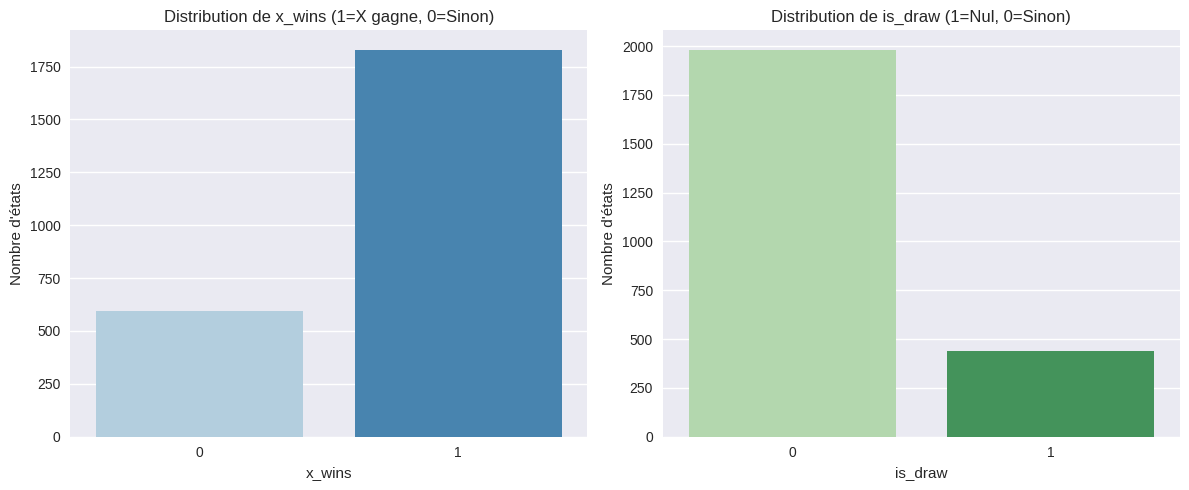


 x_wins : 75.53% des états où X gagne
 is_draw : 18.20% des états qui finissent en nul


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Distribution de x_wins
sns.countplot(data=df, x='x_wins', ax=axes[0], palette='Blues')
axes[0].set_title('Distribution de x_wins (1=X gagne, 0=Sinon)')
axes[0].set_xlabel('x_wins')
axes[0].set_ylabel('Nombre d\'états')

# Distribution de is_draw
sns.countplot(data=df, x='is_draw', ax=axes[1], palette='Greens')
axes[1].set_title('Distribution de is_draw (1=Nul, 0=Sinon)')
axes[1].set_xlabel('is_draw')
axes[1].set_ylabel('Nombre d\'états')

plt.tight_layout()
plt.show()

# Pourcentages
print(f"\n x_wins : {df['x_wins'].mean()*100:.2f}% des états où X gagne")
print(f" is_draw : {df['is_draw'].mean()*100:.2f}% des états qui finissent en nul")

## HEATMAP DES CORRÉLATIONS

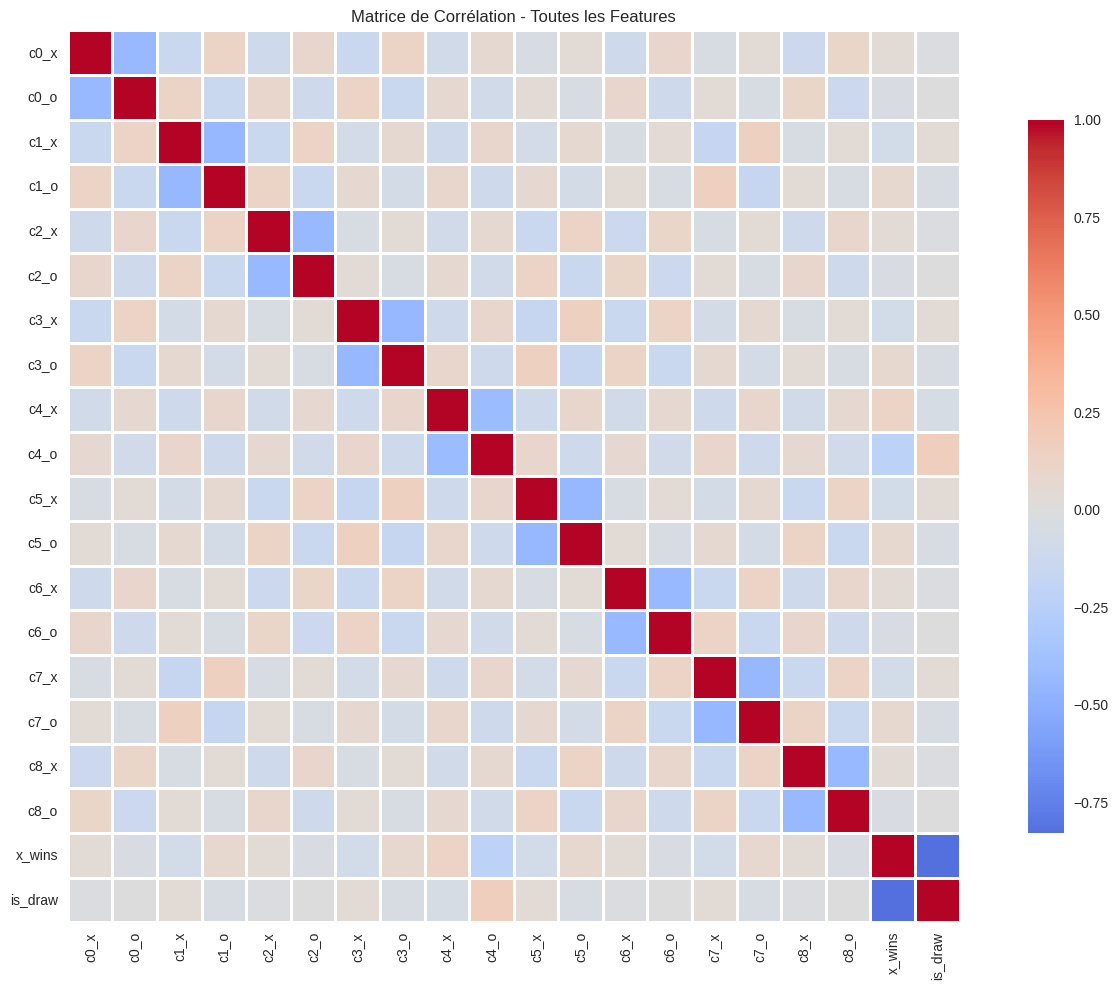


Top 5 features corrélées avec x_wins :
is_draw    0.828640
c4_o       0.222844
c4_x       0.114331
c7_x       0.082065
c5_x       0.082065
Name: x_wins, dtype: float64

Top 5 features corrélées avec is_draw :
x_wins    0.828640
c4_o      0.165334
c4_x      0.050691
c3_x      0.041658
c7_x      0.041658
Name: is_draw, dtype: float64


In [3]:
plt.figure(figsize=(14, 10))

# Calcul de la matrice de corrélation
corr_matrix = df.corr()

# Heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})

plt.title('Matrice de Corrélation - Toutes les Features')
plt.tight_layout()
plt.show()

# Corrélation avec les cibles
print("\nTop 5 features corrélées avec x_wins :")
corr_x = df.corr()['x_wins'].abs().sort_values(ascending=False)[1:6]
print(corr_x)

print("\nTop 5 features corrélées avec is_draw :")
corr_draw = df.corr()['is_draw'].abs().sort_values(ascending=False)[1:6]
print(corr_draw)

## CASES IMPORTANTES POUR GAGNER

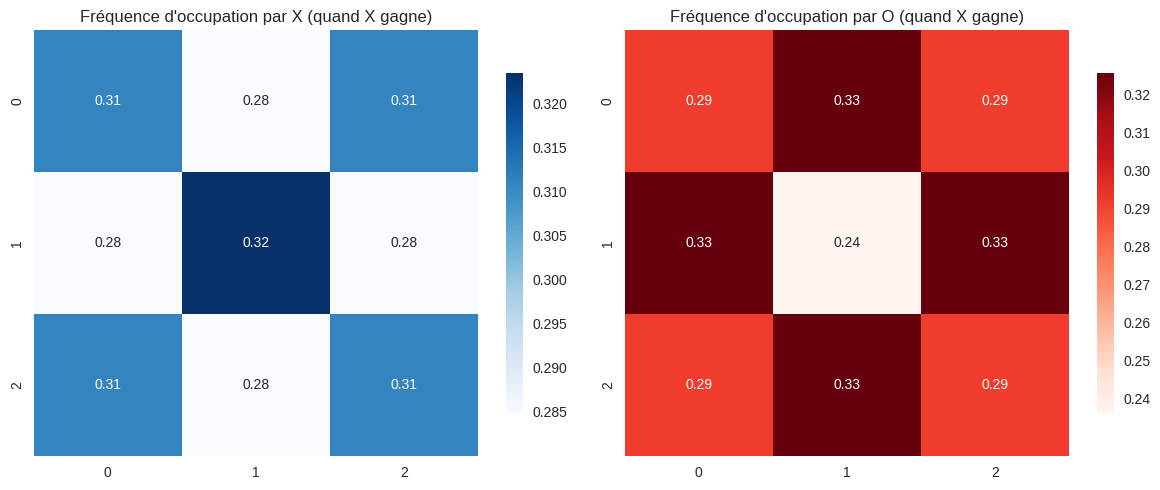


Observation : La case centrale (position 4) est-elle importante ?
   Position 4 (centre) - X : 0.32
   Position 4 (centre) - O : 0.24


In [4]:
# Moyenne de chaque case occupée par X quand X gagne
df_x_wins = df[df['x_wins'] == 1]

# Créer une grille 3x3 pour visualiser l'occupation
grid_x = np.zeros((3, 3))
grid_o = np.zeros((3, 3))

for i in range(9):
    grid_x[i//3, i%3] = df_x_wins[f'c{i}_x'].mean()
    grid_o[i//3, i%3] = df_x_wins[f'c{i}_o'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Heatmap pour X
sns.heatmap(grid_x, annot=True, fmt='.2f', cmap='Blues', ax=axes[0], 
            cbar_kws={"shrink": 0.8})
axes[0].set_title('Fréquence d\'occupation par X (quand X gagne)')

# Heatmap pour O
sns.heatmap(grid_o, annot=True, fmt='.2f', cmap='Reds', ax=axes[1],
            cbar_kws={"shrink": 0.8})
axes[1].set_title('Fréquence d\'occupation par O (quand X gagne)')

plt.tight_layout()
plt.show()

print("\nObservation : La case centrale (position 4) est-elle importante ?")
print(f"   Position 4 (centre) - X : {grid_x[1,1]:.2f}")
print(f"   Position 4 (centre) - O : {grid_o[1,1]:.2f}")

# BASELINE : REGRESSION LOGISTIQUE

## Separate feat and cible

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

features_cols = [f'c{i}_{p}' for i in range(9) for p in ['x', 'o']]
X = df[features_cols].values
y_wins = df['x_wins'].values
y_draw = df['is_draw'].values

print(f"Features : {X.shape[1]} colonnes, {X.shape[0]} lignes")
print(f"Cible x_wins : {y_wins.shape}")
print(f"Cible is_draw : {y_draw.shape}")

Features : 18 colonnes, 2423 lignes
Cible x_wins : (2423,)
Cible is_draw : (2423,)


## Split train/test (80/20)

In [6]:
X_train, X_test, y_wins_train, y_wins_test = train_test_split(
    X, y_wins, test_size=0.2, random_state=42, stratify=y_wins)

X_train, X_test, y_draw_train, y_draw_test = train_test_split(
    X, y_draw, test_size=0.2, random_state=42, stratify=y_draw)

print(f"\nTrain : {X_train.shape[0]} échantillons")
print(f"Test : {X_test.shape[0]} échantillons")


Train : 1938 échantillons
Test : 485 échantillons


## MODÈLE A : Prédire x_wins

In [7]:
# Create & Train Model
model_wins = LogisticRegression(max_iter=1000, random_state=42)
model_wins.fit(X_train, y_wins_train)

# Predict
y_wins_pred = model_wins.predict(X_test)

# Evaluate
print("MODÈLE A : x_wins")
print(f"Accuracy : {accuracy_score(y_wins_test, y_wins_pred):.4f}")
print(f"F1-Score : {f1_score(y_wins_test, y_wins_pred):.4f}")
print(f"\nMatrice de confusion :\n{confusion_matrix(y_wins_test, y_wins_pred)}")
print(f"\nRapport de classification :\n{classification_report(y_wins_test, y_wins_pred)}")

MODÈLE A : x_wins
Accuracy : 0.7546
F1-Score : 0.8602

Matrice de confusion :
[[  0 119]
 [  0 366]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       119
           1       0.75      1.00      0.86       366

    accuracy                           0.75       485
   macro avg       0.38      0.50      0.43       485
weighted avg       0.57      0.75      0.65       485



/home/athanos21/.local/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/athanos21/.local/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/athanos21/.local/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## MODÈLE B : Prédire is_draw

In [8]:
# Create & Train Model
model_draw = LogisticRegression(max_iter=1000, random_state=42)
model_draw.fit(X_train, y_draw_train)

# Predict
y_draw_pred = model_draw.predict(X_test)

# Evaluate
print("MODÈLE B : is_draw")
print(f"Accuracy : {accuracy_score(y_draw_test, y_draw_pred):.4f}")
print(f"F1-Score : {f1_score(y_draw_test, y_draw_pred):.4f}")
print(f"\nMatrice de confusion :\n{confusion_matrix(y_draw_test, y_draw_pred)}")
print(f"\nRapport de classification :\n{classification_report(y_draw_test, y_draw_pred)}")

MODÈLE B : is_draw
Accuracy : 0.8186
F1-Score : 0.0000

Matrice de confusion :
[[397   0]
 [ 88   0]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.82      1.00      0.90       397
           1       0.00      0.00      0.00        88

    accuracy                           0.82       485
   macro avg       0.41      0.50      0.45       485
weighted avg       0.67      0.82      0.74       485



/home/athanos21/.local/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/athanos21/.local/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/athanos21/.local/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## ANALYSE DES COEFFICIENTS

=== MODÈLE A : x_wins ===


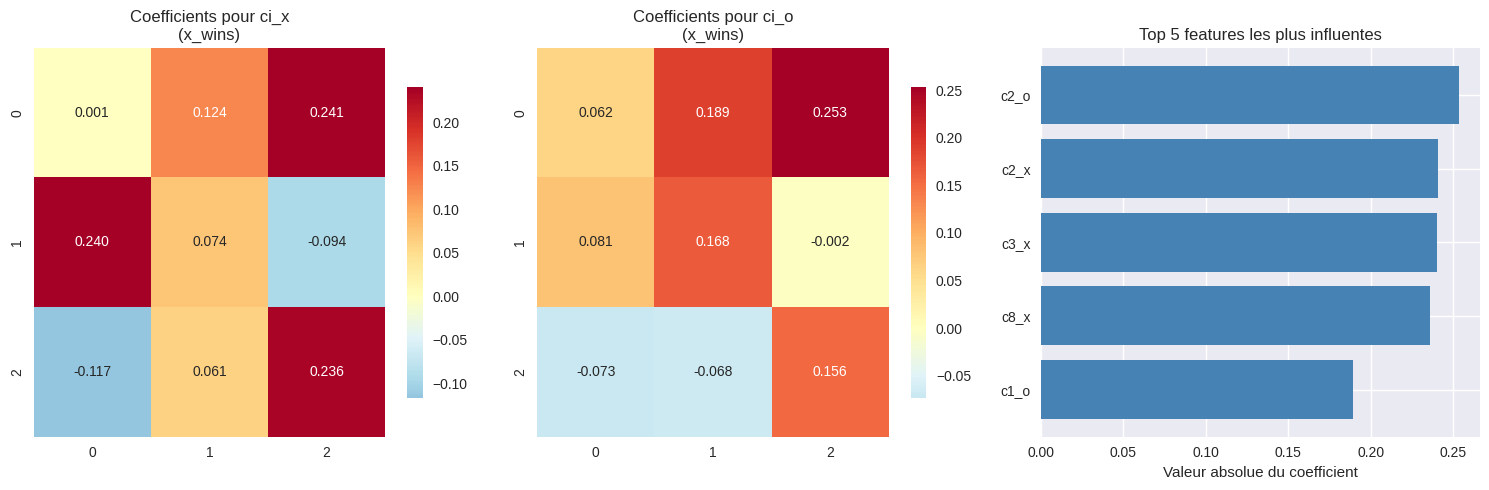


Case centrale (position 4) :
Coefficient c4_x : 0.0745
Coefficient c4_o : 0.1678

=== MODÈLE B : is_draw ===


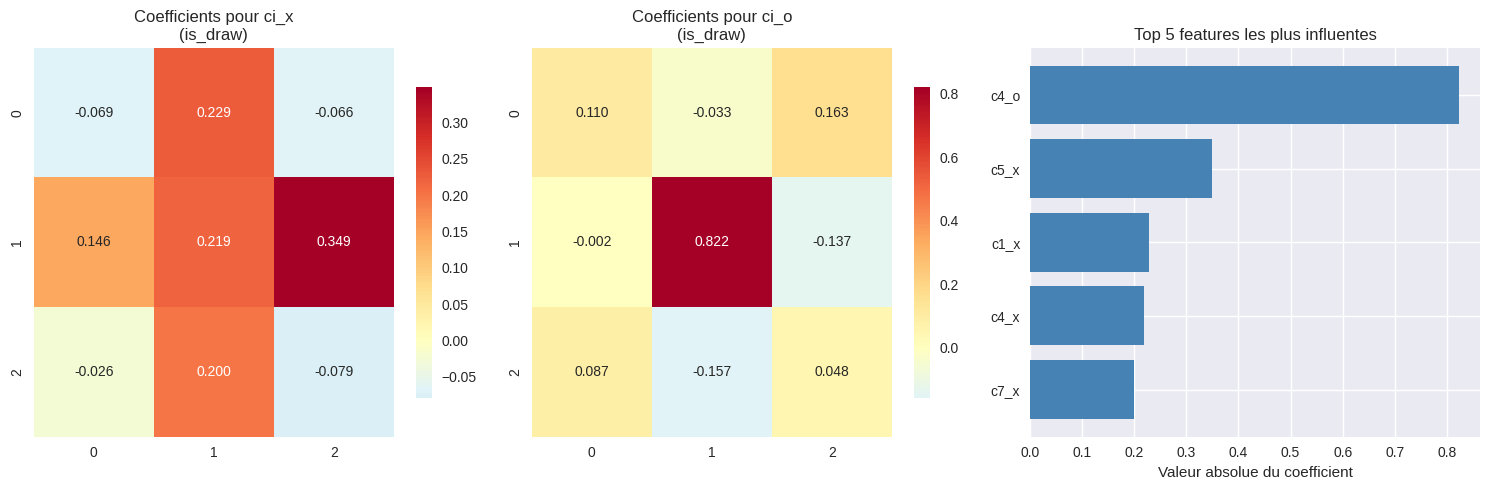


Case centrale (position 4) :
Coefficient c4_x : 0.2190
Coefficient c4_o : 0.8224


In [9]:
def plot_coefficients(model, target_name, feature_cols):
    """Visualise les coefficients sur un plateau 3x3"""
    
    # Extraire les coefficients
    coefs = model.coef_[0]
    
    # Créer deux grilles 3x3 : une pour les cases X, une pour les cases O
    grid_x = np.zeros((3, 3))
    grid_o = np.zeros((3, 3))
    
    for i in range(9):
        grid_x[i//3, i%3] = coefs[features_cols.index(f'c{i}_x')]
        grid_o[i//3, i%3] = coefs[features_cols.index(f'c{i}_o')]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Heatmap pour X
    sns.heatmap(grid_x, annot=True, fmt='.3f', cmap='RdYlBu_r', ax=axes[0], 
                cbar_kws={"shrink": 0.8}, center=0)
    axes[0].set_title(f'Coefficients pour ci_x\n({target_name})')
    
    # Heatmap pour O
    sns.heatmap(grid_o, annot=True, fmt='.3f', cmap='RdYlBu_r', ax=axes[1],
                cbar_kws={"shrink": 0.8}, center=0)
    axes[1].set_title(f'Coefficients pour ci_o\n({target_name})')
    
    # Top features
    coef_df = pd.DataFrame({'feature': feature_cols, 'coef': np.abs(coefs)})
    top5 = coef_df.nlargest(5, 'coef')
    
    axes[2].barh(top5['feature'], top5['coef'], color='steelblue')
    axes[2].set_xlabel('Valeur absolue du coefficient')
    axes[2].set_title('Top 5 features les plus influentes')
    axes[2].invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    # Afficher les valeurs de la case centrale
    center_x = coefs[features_cols.index('c4_x')]
    center_o = coefs[features_cols.index('c4_o')]
    print(f"\nCase centrale (position 4) :")
    print(f"Coefficient c4_x : {center_x:.4f}")
    print(f"Coefficient c4_o : {center_o:.4f}")

# Visualiser pour x_wins
print("=== MODÈLE A : x_wins ===")
plot_coefficients(model_wins, "x_wins", features_cols)

# Visualiser pour is_draw
print("\n=== MODÈLE B : is_draw ===")
plot_coefficients(model_draw, "is_draw", features_cols)

## Save Model for Interface

In [10]:
import joblib
import os

# Create model if not exist
os.makedirs('models', exist_ok=True)

# Save
joblib.dump(model_wins, 'models/model_x_wins.pkl')
joblib.dump(model_draw, 'models/model_is_draw.pkl')
joblib.dump(features_cols, 'models/features_cols.pkl')

print("Modèles sauvegardés dans le dossier 'models/' :")
print("- model_x_wins.pkl")
print("- model_is_draw.pkl")
print("- features_cols.pkl")

Modèles sauvegardés dans le dossier 'models/' :
- model_x_wins.pkl
- model_is_draw.pkl
- features_cols.pkl


# MODELES AVANCES

## Import

In [11]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import joblib

print("Bib imported...")

Bib imported...


## Function for evalute model

In [12]:
def evaluate_model(model, X_test, y_test, model_name, target_name):
    """Évalue un modèle et affiche les métriques"""
    
    y_pred = model.predict(X_test)
    
    print(f"\n{model_name} — Cible : {target_name}")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1-Score : {f1_score(y_test, y_pred):.4f}")
    print(f"\nMatrice de confusion :\n{confusion_matrix(y_test, y_pred)}")
    
    return accuracy_score(y_test, y_pred), f1_score(y_test, y_pred)

## DECISION TREE

### Cible: x_wins


Decision Tree — Cible : x_wins
Accuracy : 0.6454
F1-Score : 0.7707

Matrice de confusion :
[[ 24  95]
 [ 77 289]]


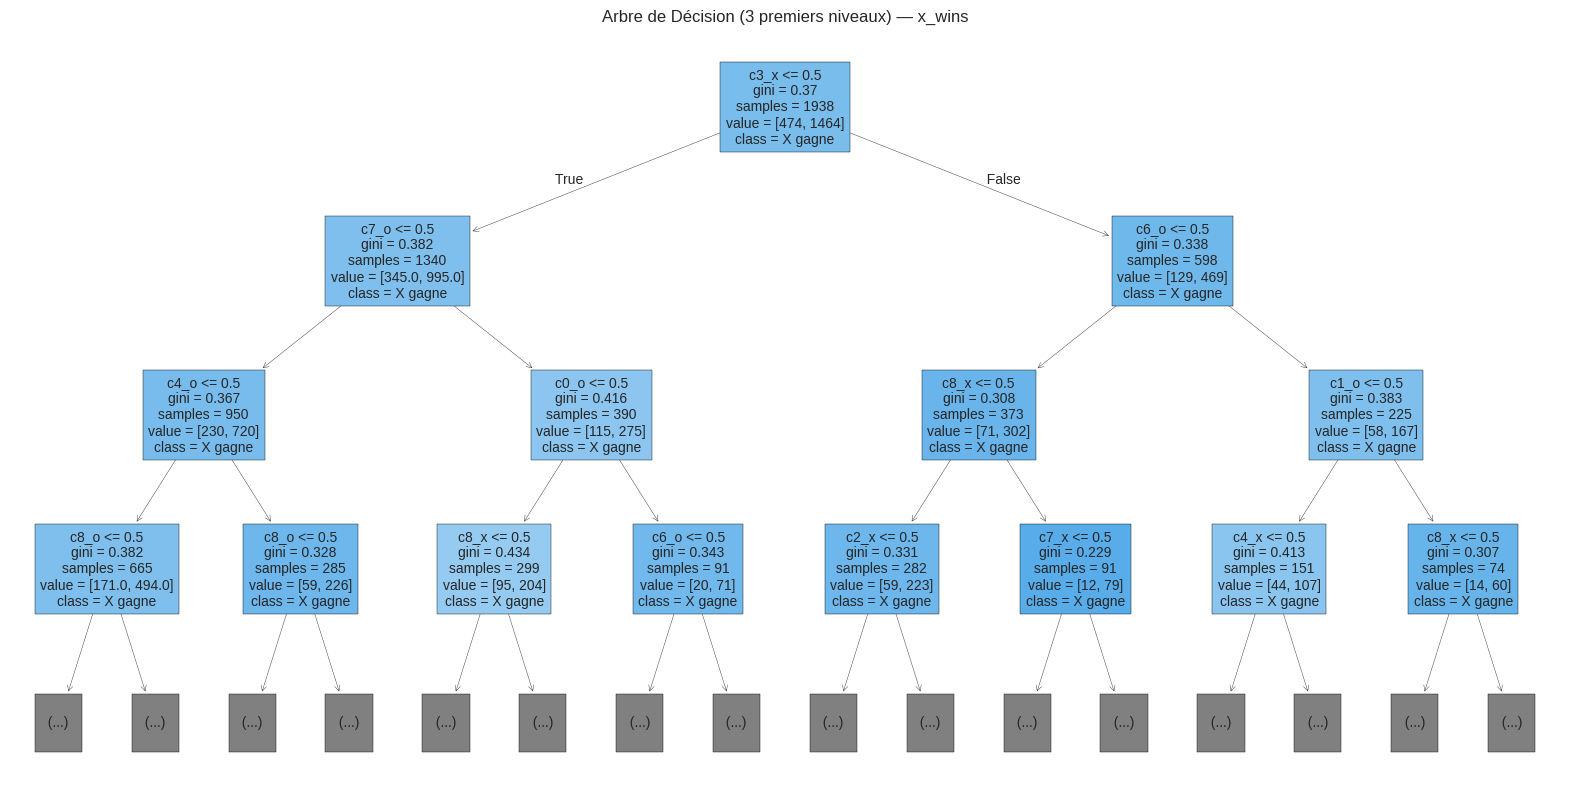

In [13]:
# Train model
dt_wins = DecisionTreeClassifier(max_depth=10, random_state=42, min_samples_split=10)
dt_wins.fit(X_train, y_wins_train)

# EValuate
acc_dt_wins, f1_dt_wins = evaluate_model(dt_wins, X_test, y_wins_test, "Decision Tree", "x_wins")

# Display
plt.figure(figsize=(20, 10))
plot_tree(dt_wins, max_depth=3, feature_names=features_cols, 
          class_names=['O gagne/Nul', 'X gagne'], filled=True, fontsize=10)
plt.title("Arbre de Décision (3 premiers niveaux) — x_wins")
plt.show()

### Cible: is_draw

In [14]:
# Train model
dt_draw = DecisionTreeClassifier(max_depth=10, random_state=42, min_samples_split=10)
dt_draw.fit(X_train, y_draw_train)

# Evaluate
acc_dt_draw, f1_dt_draw = evaluate_model(dt_draw, X_test, y_draw_test, "Decision Tree", "is_draw")


Decision Tree — Cible : is_draw
Accuracy : 0.8309
F1-Score : 0.4533

Matrice de confusion :
[[369  28]
 [ 54  34]]


## Random Forest

### x_wins

In [15]:
rf_wins = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_wins.fit(X_train, y_wins_train)
acc_rf_wins, f1_rf_wins = evaluate_model(rf_wins, X_test, y_wins_test, "Random Forest", "x_wins")


Random Forest — Cible : x_wins
Accuracy : 0.7485
F1-Score : 0.8558

Matrice de confusion :
[[  1 118]
 [  4 362]]


### is_draw

In [16]:
rf_draw = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_draw.fit(X_train, y_draw_train)
acc_rf_draw, f1_rf_draw = evaluate_model(rf_draw, X_test, y_draw_test, "Random Forest", "is_draw")


Random Forest — Cible : is_draw
Accuracy : 0.8722
F1-Score : 0.5000

Matrice de confusion :
[[392   5]
 [ 57  31]]


## Visualisation on board 3x3

RANDOM FOREST : x_wins ===


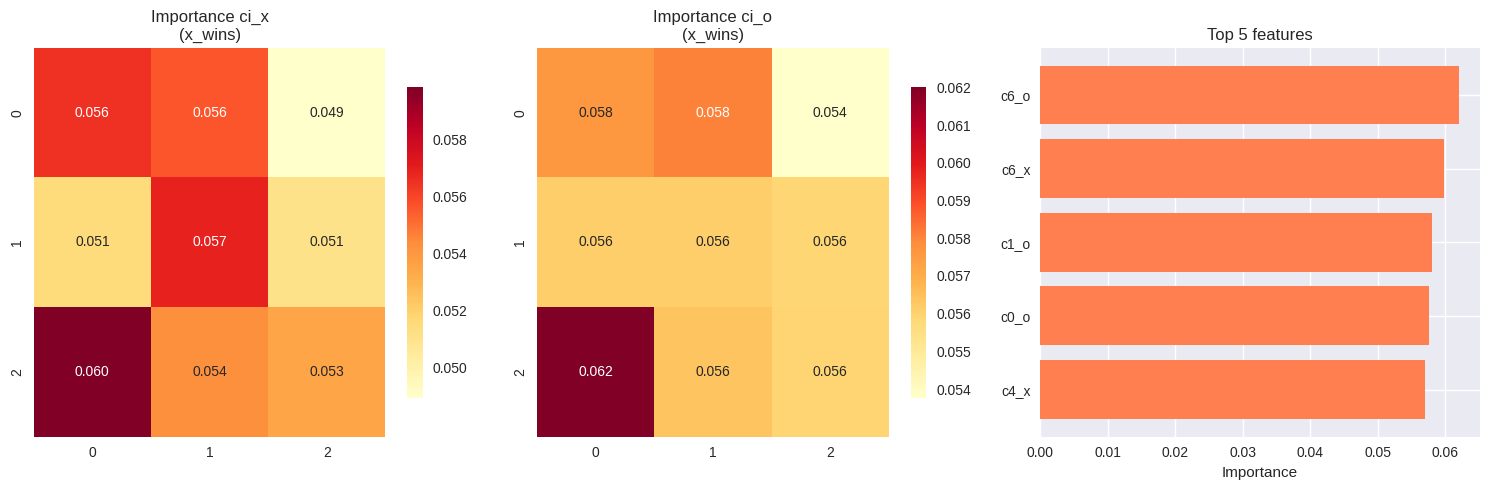


Case centrale (position 4) — Importance :
c4_x : 0.0569
c4_o : 0.0561

RANDOM FOREST : is_draw ===


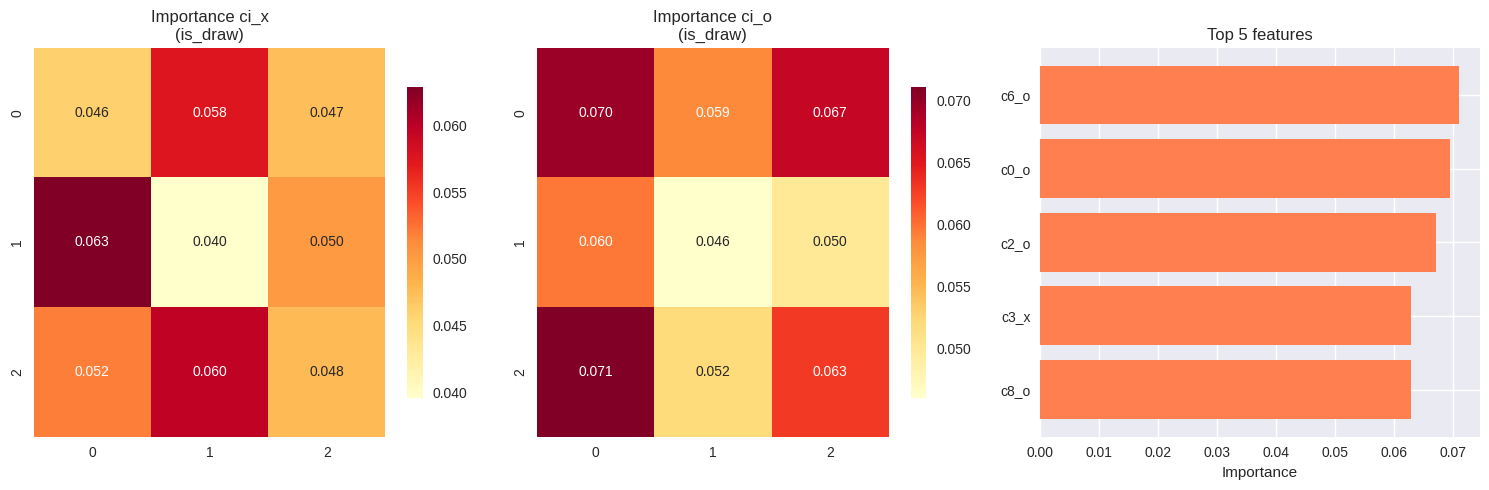


Case centrale (position 4) — Importance :
c4_x : 0.0396
c4_o : 0.0460


In [17]:
def plot_feature_importance(model, target_name, feature_cols):
    """Visualise l'importance des features sur un plateau 3x3"""
    
    importances = model.feature_importances_
    
    # Créer deux grilles 3x3
    grid_x = np.zeros((3, 3))
    grid_o = np.zeros((3, 3))
    
    for i in range(9):
        grid_x[i//3, i%3] = importances[feature_cols.index(f'c{i}_x')]
        grid_o[i//3, i%3] = importances[feature_cols.index(f'c{i}_o')]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Heatmap pour X
    sns.heatmap(grid_x, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0], 
                cbar_kws={"shrink": 0.8})
    axes[0].set_title(f'Importance ci_x\n({target_name})')
    
    # Heatmap pour O
    sns.heatmap(grid_o, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1],
                cbar_kws={"shrink": 0.8})
    axes[1].set_title(f'Importance ci_o\n({target_name})')
    
    # Top 5 features
    imp_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
    top5 = imp_df.nlargest(5, 'importance')
    
    axes[2].barh(top5['feature'], top5['importance'], color='coral')
    axes[2].set_xlabel('Importance')
    axes[2].set_title('Top 5 features')
    axes[2].invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    # Case centrale
    center_x = importances[feature_cols.index('c4_x')]
    center_o = importances[feature_cols.index('c4_o')]
    print(f"\nCase centrale (position 4) — Importance :")
    print(f"c4_x : {center_x:.4f}")
    print(f"c4_o : {center_o:.4f}")

# Pour Random Forest x_wins
print("RANDOM FOREST : x_wins ===")
plot_feature_importance(rf_wins, "x_wins", features_cols)

# Pour Random Forest is_draw
print("\nRANDOM FOREST : is_draw ===")
plot_feature_importance(rf_draw, "is_draw", features_cols)

In [18]:
## Tableau Comparatif

COMPARAISON DES MODÈLES (sur le set de test) :

       Modèle  x_wins_Accuracy  x_wins_F1  is_draw_Accuracy  is_draw_F1
       LogReg         0.754639   0.860165          0.818557    0.000000
Decision Tree         0.645361   0.770667          0.830928    0.453333
Random Forest         0.748454   0.855792          0.872165    0.500000


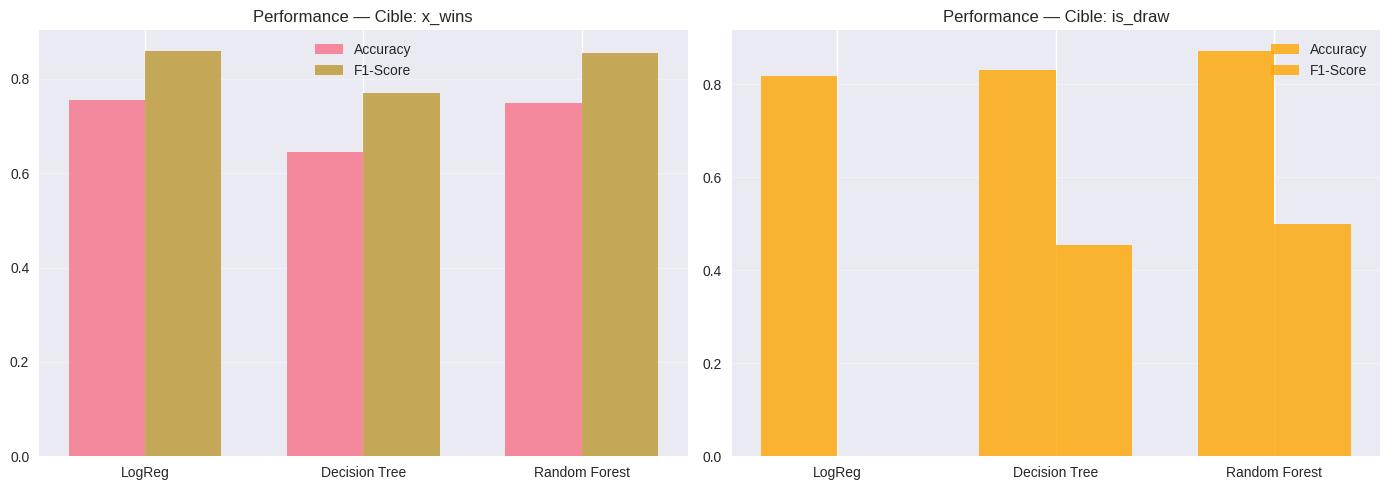

In [19]:
results = pd.DataFrame({
    'Modèle': ['LogReg', 'Decision Tree', 'Random Forest'],
    'x_wins_Accuracy': [accuracy_score(y_wins_test, model_wins.predict(X_test)), 
                        acc_dt_wins, acc_rf_wins],
    'x_wins_F1': [f1_score(y_wins_test, model_wins.predict(X_test)), 
                  f1_dt_wins, f1_rf_wins],
    'is_draw_Accuracy': [accuracy_score(y_draw_test, model_draw.predict(X_test)), 
                         acc_dt_draw, acc_rf_draw],
    'is_draw_F1': [f1_score(y_draw_test, model_draw.predict(X_test)), 
                   f1_dt_draw, f1_rf_draw]
})

print("COMPARAISON DES MODÈLES (sur le set de test) :\n")
print(results.to_string(index=False))

# Graphique comparatif
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pour x_wins
x = np.arange(3)
width = 0.35
axes[0].bar(x - width/2, results['x_wins_Accuracy'], width, label='Accuracy', alpha=0.8)
axes[0].bar(x + width/2, results['x_wins_F1'], width, label='F1-Score', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(results['Modèle'])
axes[0].set_title('Performance — Cible: x_wins')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Pour is_draw
axes[1].bar(x - width/2, results['is_draw_Accuracy'], width, label='Accuracy', alpha=0.8, color='orange')
axes[1].bar(x + width/2, results['is_draw_F1'], width, label='F1-Score', alpha=0.8, color='orange')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results['Modèle'])
axes[1].set_title('Performance — Cible: is_draw')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
## Save model

In [21]:
# On choisit Random Forest (généralement le meilleur)
best_model_wins = rf_wins
best_model_draw = rf_draw

joblib.dump(best_model_wins, 'models/best_model_x_wins.pkl')
joblib.dump(best_model_draw, 'models/best_model_is_draw.pkl')

print("Meilleurs modèles sauvegardés :")
print("- models/best_model_x_wins.pkl")
print("- models/best_model_is_draw.pkl")

Meilleurs modèles sauvegardés :
- models/best_model_x_wins.pkl
- models/best_model_is_draw.pkl
